### Cross Validation in Machine Learning

**Cross-validation** is a technique used to check how well a machine learning model performs on unseen data while preventing overfitting. It works by:

- Splitting the dataset into several parts.
- Training the model on some parts and testing it on the remaining part.
- Repeating this resampling process multiple times by choosing different parts of the dataset.
- Averaging the results from each validation step to get the final performance.

### Types of Cross-Validation
There are several types of cross-validation techniques which are as follows:

#### 1. Holdout Validation
In Holdout Validation the dataset is split into training and testing sets. Common splits include 70–30, 80–20 or 75–25 depending on the dataset size and problem. Making it simple and quick to apply.

#### 2. LOOCV (Leave One Out Cross Validation)
In this method the model is trained on the entire dataset except for one data point which is used for testing. This process is repeated for each data point in the dataset.

All data points are used for training, resulting in `low bias`.
Testing on a single data point can cause high variance, especially if the point is an outlier.
It can be very time-consuming for large datasets as it requires one iteration per data point.

#### 3. Stratified Cross-Validation
It is a technique that ensures each fold of the cross-validation process has the same class distribution as the full dataset. This is useful for imbalanced datasets where some classes are underrepresented.

The dataset is divided into k folds, keeping class proportions consistent in each fold.

In each iteration, one fold is used for testing and the remaining folds for training.

This process is repeated k times so that each fold is used once as the test set.
It helps classification models generalize better by maintaining balanced class representation.

It ensures that each fold has approximately the same class distribution as the original dataset

Example:

- Original dataset: 90% class A, 10% class B
- Each fold will also be ~90% A and 10% B

#### 4. K-Fold Cross Validation
K-Fold Cross Validation splits the dataset into k equal-sized folds. The model is trained on k-1 folds and tested on the remaining fold. This process is repeated k times each time using a different fold for testing.

It does NOT consider the distribution of the target variable

So if your dataset is imbalanced (e.g., 90% class A, 10% class B), some folds might end up with:

- Mostly class A
- Very few or even no class B

That can lead to unreliable evaluation.

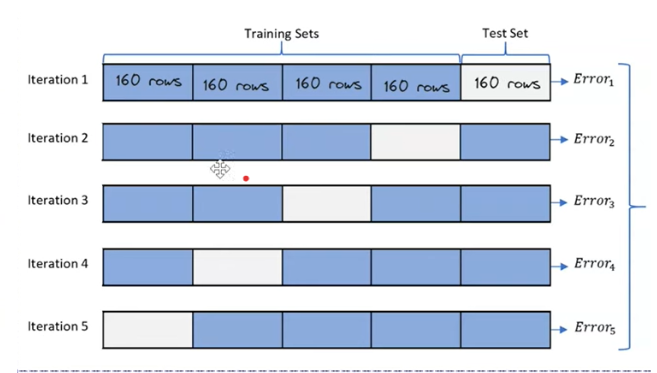

#### Python implementation for k fold cross-validation

##### Importing necessary libraries
We will import essential modules from scikit-learn.

- cross_val_score helps evaluate model performance using cross-validation.
- KFold splits the data into defined folds.
- SVC is used for Support Vector Classification.
- load_iris loads the sample dataset.

In [4]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

##### Loading the dataset
We will use the Iris dataset a built-in, multi-class dataset with 150 samples and 3 flower species (Setosa, Versicolor and Virginica).

In [5]:
iris = load_iris()

X = iris.data
y = iris.target

- X - features (inputs, e.g., petal length, sepal width in the Iris dataset)
- y - target (the flower type)

#### BEFORE Cross Validation (Single Split)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

- 20% of the data - testing
- 80% of the data - training
- 120 - training
- 30 - testing
- random_state=42
> This controls randomness.
- The split is random by default
- 42 makes it repeatable

#### Feature scaling

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

- scaling the features so they are on the same scale.
- `X_train_scaled = scaler.fit_transform(X_train)`

This does two things at once:

- fit
  - Learns from the training data:
    - Mean of each feature
    - Standard deviation
- transform
    - Uses those values to scale the data

- `X_test_scaled = scaler.transform(X_test)`

> This is VERY IMPORTANT.

- We DO NOT use fit here
- We only use transform

> Because:

- The test data must remain unseen
- We use the same scaling rules learned from training

> Critical
- `scaler.fit_transform(X_test)`
- This would mean:
    - The test data influences scaling
    - This causes data leakage

#### Why Scaling Matters

Some models (like `KNN`) depend on distance.

Without scaling:

- A feature with large values dominates

In [8]:
model = KNeighborsClassifier()

model.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


##### What KNN does:
- It stores the training data
- To make predictions, it:
    - Looks at the K closest points
    - Chooses the most common class among them

Example:

> If most nearby flowers are class 1, predict class 1

`model.fit(X_train_scaled, y_train)`

- This is where the model learns from the data

For KNN specifically:

- It doesn’t `learn formulas` like some models
It simply:
    - Stores the training data
    - Prepares to compute distances

- We’re showing the model examples of data and their correct answers so it can learn patterns.

In [9]:
y_pred = model.predict(X_test_scaled)

accuracy_before = accuracy_score(y_test, y_pred)

print("Accuracy (Before CV):", accuracy_before)

Accuracy (Before CV): 1.0


`y_pred = model.predict(X_test_scaled)`

> The model is now being tested

- It takes the test inputs (X_test_scaled)
- Predicts the labels

`accuracy_before = accuracy_score(y_test, y_pred)`

> This measures how correct the predictions are

- Accuracy formula:
    - Accuracy = (Number of correct predictions) / (Total predictions)
    - We compare what the model predicted vs the correct answers

#### AFTER Cross Validation (Better Approach)

Now do it properly using a Pipeline + Stratified K-Fold:

In [ ]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier())
])

##### What is a Pipeline?
- A pipeline is like an assembly line

- It ensures steps happen in order:

1. Scale the data
2. Train the model

Without pipeline:

- You might accidentally scale before splitting (data leakage risk)

#### Stratified K-Fold

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

- It splits the data into 5 parts (folds):

- Train on 4 folds
- Test on 1 fold
- Repeat 5 times

Why `Stratified`?

- Because it ensures:

- Each fold has the same class distribution

##### Cross Validation

In [ ]:
scores = cross_val_score(pipeline, X, y, cv=skf)

The model is:

**Repeated 5 times:**
1. Split data differently
2. Train pipeline
3. Test performance
4. Store accuracy

- We are testing the model multiple times on different parts of the data

##### Results

In [ ]:
print("Cross Validation Scores:", scores)
print("Mean Accuracy (After CV):", scores.mean())

Cross Validation Scores: [1.         0.96666667 0.93333333 1.         0.96666667]
Mean Accuracy (After CV): 0.9733333333333334


##### Mean accuracy

> This is the final performance estimate

Instead of trusting one split:

- We average all 5 results

- Instead of one exam, the model takes 5 exams and we average the score.

#### Before Cross Validation:
- Uses only one split
- Can be:
    - Lucky (too high)
    - Unlucky (too low)
    - Not reliable

#### After Cross Validation:
- Uses multiple splits
- Gives:
    - Average performance
    - More stable result
    - More reliable

- Testing once is like judging a student using one exam.
- Cross validation is like giving multiple exams and taking the average — much fairer

